<a href="https://colab.research.google.com/github/nisaa783/practical-statistics-for-data-scientists_Anisa-Khasanah/blob/main/Chapter_2_Data_and_Sampling_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Data and Sampling Distributions

Sebelum melakukan inferensi atau membangun model machine learning yang kompleks, perlu untuk memahami bagaimana variasi data dan proses pengambilan sampel bekerja. Bab ini membahas konsep dasar mengenai distribusi data, bias, teorema limit pusat, hingga teknik resampling untuk mengukur ketidakpastian statistik.

---

## 1. Bias dalam Pengambilan Sampel (Sampling & Selection Bias)
Data yang dikumpulkan sering kali tidak mencerminkan populasi yang sebenarnya secara akurat, yang dapat menyesatkan hasil analisis:
* **Sampling Bias:** Terjadi ketika sampel yang diambil gagal mewakili populasi target secara keseluruhan. Contohnya adalah *survei online* yang hanya bisa diakses oleh orang-orang yang memiliki internet, sehingga mengabaikan populasi yang tidak terhubung secara digital.
* **Selection Bias:** Kecenderungan sadar atau tidak sadar dalam memilih, menyaring, atau memanipulasi data yang mendukung hipotesis tertentu, sering kali akibat proses pencarian data yang cacat atau mengabaikan data yang hilang (*missing data*).
* **Statistical Definitions of Population vs Sample:**
  * **Populasi:** Keseluruhan objek atau subjek yang ingin diteliti karakteristiknya.
  * **Sampel:** Sebagian kecil dari populasi yang benar-benar diamati dan diukur datanya untuk merepresentasikan populasi.

---

## 2. Central Limit Theorem (Teorema Limit Pusat / CLT)
Teorema Limit Pusat adalah salah satu pilar paling penting dalam statistika inferensial:
* **Definisi:** Teorema ini menyatakan bahwa distribusi dari rata-rata sampel acak akan mendekati distribusi normal (Gaussian), terlepas dari bagaimana bentuk distribusi populasi aslinya (apakah miring/skewed, bimodal, dll), asalkan ukuran sampel ($n$) cukup besar (umumnya $n \ge 30$).
* **Manfaat:** Memungkinkan kita untuk melakukan pengujian hipotesis dan menghitung interval kepercayaan menggunakan kurva normal standar, meskipun data aslinya tidak berdistribusi normal.

---

## 3. Bootstrap Resampling dan Confidence Interval
Dalam dunia nyata, kita sering kali hanya memiliki satu sampel data dan tidak bisa mengambil sampel baru dari populasi berkali-kali. Di sinilah teknik *bootstrap* berperan:
* **Bootstrap Resampling:** Teknik non-parametrik di mana kita mengambil sampel berulang kali *dengan pengembalian* (*with replacement*) dari dataset asli yang sama untuk mensimulasikan variasi pengambilan sampel baru.
* **Standard Error (SE):** Ukuran penyebaran atau deviasi standar dari suatu estimasi statistik (seperti mean sampel) dari satu sampel ke sampel lainnya.
* **Confidence Interval (Interval Kepercayaan):** Rentang nilai yang diperkirakan memuat parameter populasi yang sebenarnya pada tingkat keyakinan tertentu (misalnya tingkat kepercayaan 95%, yang berarti jika kita mengulangi eksperimen berkali-kali, 95% interval yang dihasilkan akan mencakup nilai parameter populasi yang sebenarnya).

--- Dataset Pendapatan Peminjam Berhasil Dimuat ---
Jumlah Total Data: 50,000



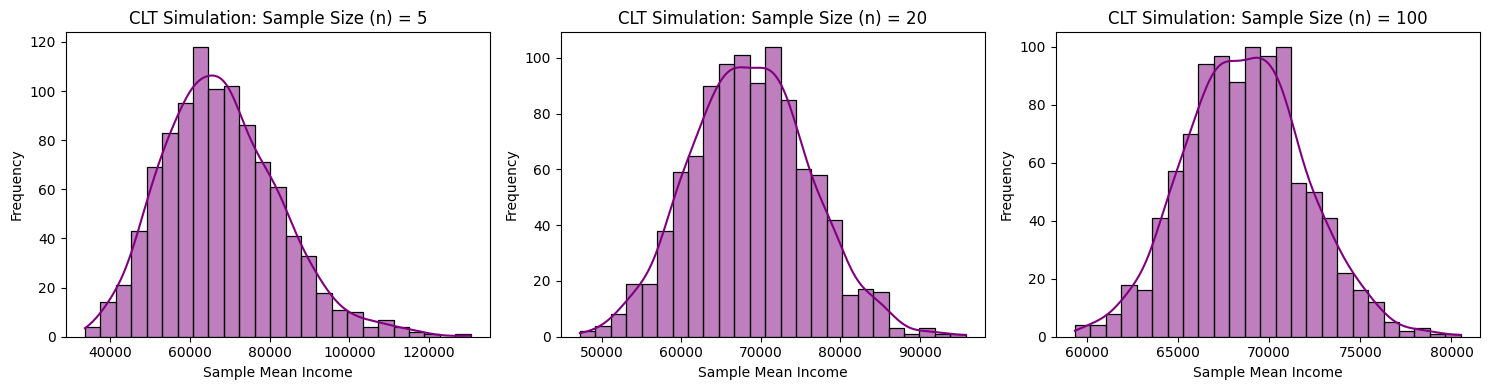

--- Hasil Analisis Confidence Interval (Bootstrap) ---
Rata-rata Pendapatan Asli (Original Mean) : $68,760.52
Standard Error (Bootstrap SE)           : $143.95
Confidence Interval 95% Lower Bound     : $68,483.11
Confidence Interval 95% Upper Bound     : $69,039.01



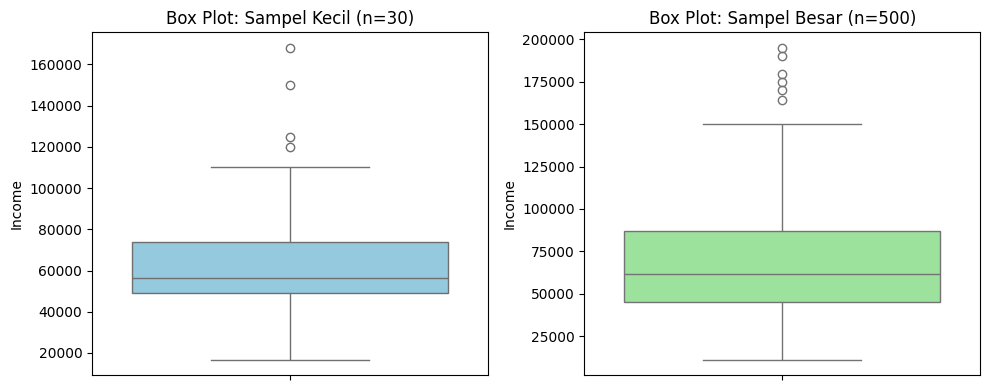

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PERSIAPAN: Memuat Dataset
# ==========================================
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/loans_income.csv"
loans_income = pd.read_csv(url).squeeze()

print("--- Dataset Pendapatan Peminjam Berhasil Dimuat ---")
print(f"Jumlah Total Data: {len(loans_income):,}\n")


# ==========================================
# CONTOH PROGRAM 1: Simulasi Central Limit Theorem (CLT)
# ==========================================
# Program ini menunjukkan bagaimana rata-rata sampel berubah bentuk menjadi
# distribusi normal saat ukuran sampel (n) diperbesar, meskipun data aslinya miring.
np.random.seed(42)
sample_sizes = [5, 20, 100]

plt.figure(figsize=(15, 4))
for i, n in enumerate(sample_sizes, 1):
    # Mengambil rata-rata dari 1000 kali pengambilan sampel berukuran n
    means = [loans_income.sample(n=n).mean() for _ in range(1000)]

    plt.subplot(1, 3, i)
    sns.histplot(means, kde=True, color='purple', bins=25)
    plt.title(f'CLT Simulation: Sample Size (n) = {n}')
    plt.xlabel('Sample Mean Income')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# ==========================================
# CONTOH PROGRAM 2: Bootstrap Resampling & Confidence Interval
# ==========================================
# Menggunakan metode bootstrap untuk menghitung interval kepercayaan 95%
# dari rata-rata pendapatan tanpa asumsi distribusi teoretis.
np.random.seed(42)
n_bootstraps = 1000
boot_means = []

for _ in range(n_bootstraps):
    sample = loans_income.sample(n=len(loans_income), replace=True)
    boot_means.append(sample.mean())

boot_means = pd.Series(boot_means)

# Menghitung batas persentil 2.5% dan 97.5% untuk tingkat kepercayaan 95%
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print("--- Hasil Analisis Confidence Interval (Bootstrap) ---")
print(f"Rata-rata Pendapatan Asli (Original Mean) : ${loans_income.mean():,.2f}")
print(f"Standard Error (Bootstrap SE)           : ${boot_means.std():,.2f}")
print(f"Confidence Interval 95% Lower Bound     : ${ci_lower:,.2f}")
print(f"Confidence Interval 95% Upper Bound     : ${ci_upper:,.2f}\n")


# ==========================================
# CONTOH PROGRAM 3: Perbandingan Box Plot Variasi Sampel
# ==========================================
# Membandingkan sebaran, kuartil, dan outlier antara sampel kecil dan sampel besar
np.random.seed(10)
sample_small = loans_income.sample(n=30)
sample_large = loans_income.sample(n=500)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=sample_small, color='skyblue')
plt.title('Box Plot: Sampel Kecil (n=30)')
plt.ylabel('Income')

plt.subplot(1, 2, 2)
sns.boxplot(y=sample_large, color='lightgreen')
plt.title('Box Plot: Sampel Besar (n=500)')
plt.ylabel('Income')

plt.tight_layout()
plt.show()